<a href="https://colab.research.google.com/github/Innocent-I/Smart-Irrigation-ML/blob/main/notebooks/05_iot_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Irrigation ML — IoT Sensor Simulation

## V2: Real-Time Irrigation Decision System

This notebook extends the Smart Irrigation ML project from offline machine learning analysis toward an IoT-based irrigation decision system.

The objective is to simulate incoming environmental sensor measurements and use the trained decision logic to generate irrigation recommendations.

### Simulated Sensor Inputs

- Soil Moisture
- Temperature
- Air Humidity

### System Output

- Pump OFF (0)
- Pump ON (1)

### Workflow

Sensor Readings → Data Processing → Irrigation Decision → Pump Recommendation

This notebook initially uses simulated sensor readings. Future versions can replace the simulated inputs with measurements received from physical IoT sensors.

In [1]:
import pandas as pd
import numpy as np
import time

In [2]:
sensor_reading = {
    "Soil Moisture": 520.0,
    "Temperature": 29.5,
    "Air Humidity": 61.0
}

sensor_data = pd.DataFrame([sensor_reading])

print("Current Sensor Reading")
display(sensor_data)

Current Sensor Reading


,Soil Moisture,Temperature,Air Humidity
0,520.0,29.5,61.0


In [3]:
SOIL_MOISTURE_THRESHOLD = 682.58

soil_moisture = sensor_reading["Soil Moisture"]

if soil_moisture < SOIL_MOISTURE_THRESHOLD:
    pump_status = 1
    recommendation = "PUMP ON"
else:
    pump_status = 0
    recommendation = "PUMP OFF"

print("Soil Moisture:", soil_moisture)
print("Decision:", recommendation)

Soil Moisture: 520.0
Decision: PUMP ON


In [4]:
def simulate_sensor_reading():
    return {
        "Soil Moisture": round(np.random.uniform(350, 900), 2),
        "Temperature": round(np.random.uniform(20, 38), 2),
        "Air Humidity": round(np.random.uniform(40, 80), 2)
    }

reading = simulate_sensor_reading()
print(reading)

{'Soil Moisture': 416.85, 'Temperature': 24.01, 'Air Humidity': 68.55}


In [5]:
SOIL_MOISTURE_THRESHOLD = 682.58

def irrigation_decision(soil_moisture):
    if soil_moisture < SOIL_MOISTURE_THRESHOLD:
        return 1, "PUMP ON"
    else:
        return 0, "PUMP OFF"

reading = simulate_sensor_reading()

status, decision = irrigation_decision(
    reading["Soil Moisture"]
)

print("Sensor Reading:", reading)
print("Irrigation Decision:", decision)

Sensor Reading: {'Soil Moisture': 588.03, 'Temperature': 26.06, 'Air Humidity': 67.42}
Irrigation Decision: PUMP ON


In [6]:
sensor_history = []

for i in range(10):

    reading = simulate_sensor_reading()

    status, decision = irrigation_decision(
        reading["Soil Moisture"]
    )

    reading["Pump Status"] = status
    reading["Decision"] = decision

    sensor_history.append(reading)

    print(
        f"Reading {i+1}: "
        f"Soil Moisture={reading['Soil Moisture']}, "
        f"Temperature={reading['Temperature']}°C, "
        f"Humidity={reading['Air Humidity']}%, "
        f"Decision={decision}"
    )

    time.sleep(1)

Reading 1: Soil Moisture=637.83, Temperature=28.76°C, Humidity=65.4%, Decision=PUMP ON
Reading 2: Soil Moisture=443.51, Temperature=29.41°C, Humidity=40.87%, Decision=PUMP ON
Reading 3: Soil Moisture=665.97, Temperature=37.99°C, Humidity=52.91%, Decision=PUMP ON
Reading 4: Soil Moisture=853.92, Temperature=22.64°C, Humidity=44.82%, Decision=PUMP OFF
Reading 5: Soil Moisture=695.22, Temperature=31.08°C, Humidity=52.25%, Decision=PUMP OFF
Reading 6: Soil Moisture=714.71, Temperature=28.85°C, Humidity=70.8%, Decision=PUMP OFF
Reading 7: Soil Moisture=404.22, Temperature=23.03°C, Humidity=50.96%, Decision=PUMP ON
Reading 8: Soil Moisture=435.26, Temperature=20.27°C, Humidity=43.91%, Decision=PUMP ON
Reading 9: Soil Moisture=709.69, Temperature=37.67°C, Humidity=67.49%, Decision=PUMP OFF
Reading 10: Soil Moisture=701.23, Temperature=34.98°C, Humidity=50.15%, Decision=PUMP OFF


In [7]:
sensor_history = []

for i in range(10):

    reading = simulate_sensor_reading()

    status, decision = irrigation_decision(
        reading["Soil Moisture"]
    )

    reading["Pump Status"] = status
    reading["Decision"] = decision

    sensor_history.append(reading)

    print(
        f"Reading {i+1}: "
        f"Soil Moisture={reading['Soil Moisture']}, "
        f"Temperature={reading['Temperature']}°C, "
        f"Humidity={reading['Air Humidity']}%, "
        f"Decision={decision}"
    )

    time.sleep(1)

Reading 1: Soil Moisture=548.52, Temperature=27.8°C, Humidity=78.25%, Decision=PUMP ON
Reading 2: Soil Moisture=466.28, Temperature=23.9°C, Humidity=66.07%, Decision=PUMP ON
Reading 3: Soil Moisture=510.4, Temperature=20.16°C, Humidity=45.03%, Decision=PUMP ON
Reading 4: Soil Moisture=707.35, Temperature=33.39°C, Humidity=72.68%, Decision=PUMP OFF
Reading 5: Soil Moisture=549.94, Temperature=32.63°C, Humidity=63.6%, Decision=PUMP ON
Reading 6: Soil Moisture=897.52, Temperature=35.28°C, Humidity=57.56%, Decision=PUMP OFF
Reading 7: Soil Moisture=435.19, Temperature=34.66°C, Humidity=42.48%, Decision=PUMP ON
Reading 8: Soil Moisture=760.71, Temperature=29.81°C, Humidity=61.98%, Decision=PUMP OFF
Reading 9: Soil Moisture=388.87, Temperature=20.78°C, Humidity=51.99%, Decision=PUMP ON
Reading 10: Soil Moisture=814.59, Temperature=31.17°C, Humidity=55.46%, Decision=PUMP OFF


In [8]:
sensor_history_df = pd.DataFrame(sensor_history)

display(sensor_history_df)

,Soil Moisture,Temperature,Air Humidity,Pump Status,Decision
0,548.52,27.80,78.25,1,PUMP ON
1,466.28,23.90,66.07,1,PUMP ON
2,510.40,20.16,45.03,1,PUMP ON
3,707.35,33.39,72.68,0,PUMP OFF
4,549.94,32.63,63.60,1,PUMP ON
5,897.52,35.28,57.56,0,PUMP OFF
6,435.19,34.66,42.48,1,PUMP ON
7,760.71,29.81,61.98,0,PUMP OFF
8,388.87,20.78,51.99,1,PUMP ON
9,814.59,31.17,55.46,0,PUMP OFF


In [9]:
from datetime import datetime

In [10]:
sensor_history = []

for i in range(10):

    reading = simulate_sensor_reading()

    status, decision = irrigation_decision(
        reading["Soil Moisture"]
    )

    reading["Timestamp"] = datetime.now()
    reading["Pump Status"] = status
    reading["Decision"] = decision

    sensor_history.append(reading)

    print(
        f"{reading['Timestamp'].strftime('%H:%M:%S')} | "
        f"Soil={reading['Soil Moisture']} | "
        f"Temp={reading['Temperature']}°C | "
        f"Humidity={reading['Air Humidity']}% | "
        f"{decision}"
    )

    time.sleep(1)

sensor_history_df = pd.DataFrame(sensor_history)

display(sensor_history_df)

14:13:27 | Soil=897.65 | Temp=30.59°C | Humidity=73.89% | PUMP OFF
14:13:28 | Soil=581.26 | Temp=37.0°C | Humidity=46.77% | PUMP ON
14:13:29 | Soil=754.24 | Temp=24.08°C | Humidity=63.19% | PUMP OFF
14:13:30 | Soil=511.0 | Temp=34.78°C | Humidity=59.8% | PUMP ON
14:13:32 | Soil=365.3 | Temp=22.9°C | Humidity=73.94% | PUMP ON
14:13:33 | Soil=730.52 | Temp=28.17°C | Humidity=79.03% | PUMP OFF
14:13:34 | Soil=380.25 | Temp=28.96°C | Humidity=45.13% | PUMP ON
14:13:35 | Soil=894.72 | Temp=27.16°C | Humidity=40.1% | PUMP OFF
14:13:36 | Soil=573.14 | Temp=32.44°C | Humidity=48.26% | PUMP ON
14:13:37 | Soil=699.37 | Temp=35.22°C | Humidity=63.55% | PUMP OFF


,Soil Moisture,Temperature,Air Humidity,Timestamp,Pump Status,Decision
0,897.65,30.59,73.89,2026-10-04 14:13:27.998628,0,PUMP OFF
1,581.26,37.00,46.77,2026-10-04 14:13:28.998997,1,PUMP ON
2,754.24,24.08,63.19,2026-10-04 14:13:29.999341,0,PUMP OFF
3,511.00,34.78,59.80,2026-10-04 14:13:30.999754,1,PUMP ON
4,365.30,22.90,73.94,2026-10-04 14:13:32.000181,1,PUMP ON
5,730.52,28.17,79.03,2026-10-04 14:13:33.000572,0,PUMP OFF
6,380.25,28.96,45.13,2026-10-04 14:13:34.001020,1,PUMP ON
7,894.72,27.16,40.10,2026-10-04 14:13:35.001459,0,PUMP OFF
8,573.14,32.44,48.26,2026-10-04 14:13:36.002028,1,PUMP ON
9,699.37,35.22,63.55,2026-10-04 14:13:37.002776,0,PUMP OFF


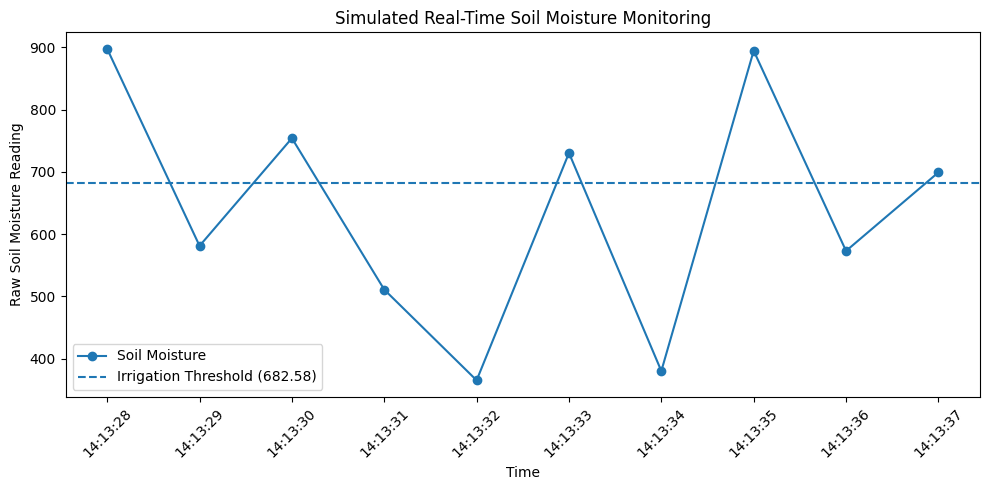

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    sensor_history_df["Timestamp"],
    sensor_history_df["Soil Moisture"],
    marker="o",
    label="Soil Moisture"
)

plt.axhline(
    y=SOIL_MOISTURE_THRESHOLD,
    linestyle="--",
    label=f"Irrigation Threshold ({SOIL_MOISTURE_THRESHOLD:.2f})"
)

plt.xlabel("Time")
plt.ylabel("Raw Soil Moisture Reading")
plt.title("Simulated Real-Time Soil Moisture Monitoring")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

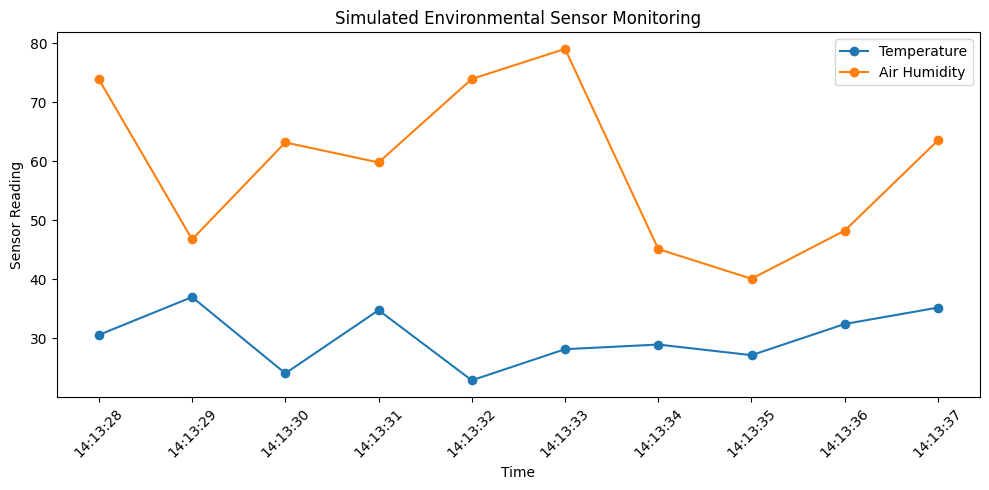

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    sensor_history_df["Timestamp"],
    sensor_history_df["Temperature"],
    marker="o",
    label="Temperature"
)

plt.plot(
    sensor_history_df["Timestamp"],
    sensor_history_df["Air Humidity"],
    marker="o",
    label="Air Humidity"
)

plt.xlabel("Time")
plt.ylabel("Sensor Reading")
plt.title("Simulated Environmental Sensor Monitoring")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Load original training dataset
dataset_url = "https://raw.githubusercontent.com/Innocent-I/Smart-Irrigation-ML/main/data/raw/smart_irrigation_data.csv"

training_df = pd.read_csv(dataset_url)

X = training_df[
    ["Soil Moisture", "Temperature", "Air Humidity"]
]

y = training_df["Pump Data"]

iot_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

iot_rf_model.fit(X, y)

print("Random Forest model ready for IoT predictions.")

Random Forest model ready for IoT predictions.


In [15]:
comparison_data = sensor_history_df.copy()

# Threshold predictions
comparison_data["Threshold Prediction"] = (
    comparison_data["Soil Moisture"] < SOIL_MOISTURE_THRESHOLD
).astype(int)

# Random Forest predictions
comparison_data["ML Prediction"] = iot_rf_model.predict(
    comparison_data[
        ["Soil Moisture", "Temperature", "Air Humidity"]
    ]
)

# Convert numerical predictions to readable labels
comparison_data["Threshold Decision"] = comparison_data[
    "Threshold Prediction"
].map({
    0: "PUMP OFF",
    1: "PUMP ON"
})

comparison_data["ML Decision"] = comparison_data[
    "ML Prediction"
].map({
    0: "PUMP OFF",
    1: "PUMP ON"
})

# Check agreement
comparison_data["Agreement"] = (
    comparison_data["Threshold Prediction"]
    == comparison_data["ML Prediction"]
)

display(
    comparison_data[
        [
            "Timestamp",
            "Soil Moisture",
            "Temperature",
            "Air Humidity",
            "Threshold Decision",
            "ML Decision",
            "Agreement"
        ]
    ]
)

,Timestamp,Soil Moisture,Temperature,Air Humidity,Threshold Decision,ML Decision,Agreement
0,2026-10-04 14:13:27.998628,897.65,30.59,73.89,PUMP OFF,PUMP OFF,True
1,2026-10-04 14:13:28.998997,581.26,37.00,46.77,PUMP ON,PUMP ON,True
2,2026-10-04 14:13:29.999341,754.24,24.08,63.19,PUMP OFF,PUMP OFF,True
3,2026-10-04 14:13:30.999754,511.00,34.78,59.80,PUMP ON,PUMP ON,True
4,2026-10-04 14:13:32.000181,365.30,22.90,73.94,PUMP ON,PUMP ON,True
5,2026-10-04 14:13:33.000572,730.52,28.17,79.03,PUMP OFF,PUMP OFF,True
6,2026-10-04 14:13:34.001020,380.25,28.96,45.13,PUMP ON,PUMP ON,True
7,2026-10-04 14:13:35.001459,894.72,27.16,40.10,PUMP OFF,PUMP OFF,True
8,2026-10-04 14:13:36.002028,573.14,32.44,48.26,PUMP ON,PUMP ON,True
9,2026-10-04 14:13:37.002776,699.37,35.22,63.55,PUMP OFF,PUMP OFF,True


In [16]:
agreement_rate = comparison_data["Agreement"].mean() * 100

print(
    f"Threshold vs Random Forest agreement: "
    f"{agreement_rate:.2f}%"
)

print(
    "Number of disagreements:",
    (~comparison_data["Agreement"]).sum()
)

Threshold vs Random Forest agreement: 100.00%
Number of disagreements: 0


In [17]:
boundary_test = pd.DataFrame({
    "Soil Moisture": [
        675, 678, 680, 681,
        681.5, 681.7, 682,
        682.3, 682.5, 682.58,
        682.7, 683, 684, 685, 690
    ],
    "Temperature": [29.0] * 15,
    "Air Humidity": [60.0] * 15
})

# Threshold prediction
boundary_test["Threshold Prediction"] = (
    boundary_test["Soil Moisture"] < SOIL_MOISTURE_THRESHOLD
).astype(int)

# ML prediction
boundary_test["ML Prediction"] = iot_rf_model.predict(
    boundary_test[
        ["Soil Moisture", "Temperature", "Air Humidity"]
    ]
)

boundary_test["Threshold Decision"] = boundary_test[
    "Threshold Prediction"
].map({0: "PUMP OFF", 1: "PUMP ON"})

boundary_test["ML Decision"] = boundary_test[
    "ML Prediction"
].map({0: "PUMP OFF", 1: "PUMP ON"})

boundary_test["Agreement"] = (
    boundary_test["Threshold Prediction"]
    == boundary_test["ML Prediction"]
)

display(
    boundary_test[
        [
            "Soil Moisture",
            "Temperature",
            "Air Humidity",
            "Threshold Decision",
            "ML Decision",
            "Agreement"
        ]
    ]
)

,Soil Moisture,Temperature,Air Humidity,Threshold Decision,ML Decision,Agreement
0,675.00,29.0,60.0,PUMP ON,PUMP ON,True
1,678.00,29.0,60.0,PUMP ON,PUMP ON,True
2,680.00,29.0,60.0,PUMP ON,PUMP ON,True
3,681.00,29.0,60.0,PUMP ON,PUMP ON,True
4,681.50,29.0,60.0,PUMP ON,PUMP ON,True
5,681.70,29.0,60.0,PUMP ON,PUMP ON,True
6,682.00,29.0,60.0,PUMP ON,PUMP OFF,False
7,682.30,29.0,60.0,PUMP ON,PUMP OFF,False
8,682.50,29.0,60.0,PUMP ON,PUMP OFF,False
9,682.58,29.0,60.0,PUMP OFF,PUMP OFF,True


In [18]:
disagreements = boundary_test[
    boundary_test["Agreement"] == False
]

print("Boundary test observations:", len(boundary_test))
print("Number of disagreements:", len(disagreements))

if len(disagreements) > 0:
    print("\nDisagreement cases:")
    display(disagreements)
else:
    print("\nNo disagreements detected near the tested boundary.")

Boundary test observations: 15
Number of disagreements: 3

Disagreement cases:


,Soil Moisture,Temperature,Air Humidity,Threshold Prediction,ML Prediction,Threshold Decision,ML Decision,Agreement
6,682.0,29.0,60.0,1,0,PUMP ON,PUMP OFF,False
7,682.3,29.0,60.0,1,0,PUMP ON,PUMP OFF,False
8,682.5,29.0,60.0,1,0,PUMP ON,PUMP OFF,False


In [19]:
test_conditions = []

for temperature in [20, 25, 30, 35, 38]:
    for humidity in [40, 50, 60, 70, 80]:

        test_conditions.append({
            "Soil Moisture": 682.3,
            "Temperature": temperature,
            "Air Humidity": humidity
        })

condition_test = pd.DataFrame(test_conditions)

condition_test["ML Prediction"] = iot_rf_model.predict(
    condition_test[
        ["Soil Moisture", "Temperature", "Air Humidity"]
    ]
)

condition_test["ML Decision"] = condition_test[
    "ML Prediction"
].map({
    0: "PUMP OFF",
    1: "PUMP ON"
})

display(condition_test)

,Soil Moisture,Temperature,Air Humidity,ML Prediction,ML Decision
0,682.3,20,40,0,PUMP OFF
1,682.3,20,50,0,PUMP OFF
2,682.3,20,60,0,PUMP OFF
3,682.3,20,70,0,PUMP OFF
4,682.3,20,80,0,PUMP OFF
5,682.3,25,40,0,PUMP OFF
6,682.3,25,50,0,PUMP OFF
7,682.3,25,60,0,PUMP OFF
8,682.3,25,70,0,PUMP OFF
9,682.3,25,80,0,PUMP OFF


In [20]:
summary = pd.crosstab(
    condition_test["Temperature"],
    condition_test["Air Humidity"],
    values=condition_test["ML Prediction"],
    aggfunc="first"
)

print("Random Forest decision at Soil Moisture = 682.3")
print("1 = PUMP ON, 0 = PUMP OFF")

display(summary)

Random Forest decision at Soil Moisture = 682.3
1 = PUMP ON, 0 = PUMP OFF


Air Humidity,40,50,60,70,80
Temperature,,,,,
20,0,0,0,0,0
25,0,0,0,0,0
30,0,0,0,0,0
35,0,0,0,0,0
38,0,0,0,0,0


In [ ]:
## Decision-Boundary Sensitivity Analysis

A targeted stress test was performed around the Soil Moisture decision boundary.

The threshold-based controller and Random Forest disagreed for several readings close to the boundary. At Soil Moisture values of approximately **682.0, 682.3, and 682.5**, the threshold controller recommended PUMP ON while Random Forest predicted PUMP OFF.

To investigate whether Temperature or Air Humidity influenced this difference, Soil Moisture was fixed at **682.3** while:

- Temperature was varied from **20°C to 38°C**
- Air Humidity was varied from **40% to 80%**

Across all **25 combinations**, Random Forest consistently predicted **PUMP OFF**.

### Interpretation

Within the tested ranges, Temperature and Air Humidity did not alter the Random Forest decision at Soil Moisture = 682.3.

This provides additional evidence that the model's decision boundary is primarily controlled by Soil Moisture. The small difference between the threshold controller and Random Forest near the boundary should not be interpreted as evidence that Random Forest has learned a superior physical irrigation rule.

Instead, it likely reflects how the model learned the decision structure of the available training dataset.